# Spectral Filtering + VAW (Vovk-Azoury-Warmuth)

This notebook presents a practical implementation of **Spectral Filtering** combined with the **VAW (Vovk-Azoury-Warmuth)** online learning algorithm for sequential prediction in linear dynamical systems.

The objective is to demonstrate how temporal dynamics can be represented in a compact spectral basis using Hankel matrices and Singular Value Decomposition (SVD), while an online second-order learning algorithm adaptively estimates the system behavior over time.

The notebook is organized into the following steps:

1. Simulation of a Linear Dynamical System (LDS)
2. Construction of the Hankel matrix
3. Spectral decomposition using SVD
4. Extraction of spectral features
5. Online learning using the VAW algorithm
6. Sequential prediction and evaluation
7. Visualization of predictions and spectral filters

This implementation is inspired by modern approaches in:

- Online Control
- Online Convex Optimization
- Spectral Filtering
- State Space Models
- Adaptive Filtering
- Sequential Prediction

The methodology follows ideas presented in the literature of Online Nonstochastic Control and Spectral Learning for Linear Dynamical Systems.

# Importing Libraries

In this section, we import the fundamental libraries required for the implementation.

The project relies primarily on:

- `NumPy` for numerical linear algebra operations;
- `Matplotlib` for visualization and analysis of the results.

Linear dynamical systems, spectral decompositions, and online learning algorithms are fundamentally matrix-based methods. Therefore, efficient numerical computation is essential.

The use of NumPy is particularly important because:

- state-space models are naturally represented using matrices;
- Singular Value Decomposition (SVD) is a linear algebra operation;
- online optimization algorithms frequently require vectorized computations.

Matplotlib is used to visually interpret:

- the prediction quality;
- the temporal behavior of the system;
- the learned spectral filters.

Visualization is important because spectral methods are highly geometric in nature. Many insights become clearer when observing the filters and predictions graphically.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Generating a Linear Dynamical System

In this section, we simulate a simple Linear Dynamical System (LDS).

The purpose of this step is to generate sequential data with temporal dependencies, allowing us to test spectral filtering and online learning techniques.

The system follows the standard state-space representation:

\[
x_{t+1} = Ax_t + Bu_t + w_t
\]

\[
y_t = Cx_t
\]

where:

- \(x_t\) is the hidden state;
- \(u_t\) is the control/input signal;
- \(w_t\) is a noise perturbation;
- \(y_t\) is the observed output.

The matrices:

- \(A\) define the system dynamics;
- \(B\) define how inputs affect the state;
- \(C\) define how the hidden state is observed.

The chosen system is intentionally stable because spectral filtering techniques are easier to analyze and interpret in stable systems.

Noise is added to simulate realistic conditions. In practical systems, measurements and dynamics are rarely noise-free due to:

- sensor inaccuracies;
- external disturbances;
- model mismatch;
- environmental uncertainties.

The generated output signal will later be transformed into a spectral representation.

In [25]:
# ============================================================
# 1. Generating a simple linear dynamical system
# ============================================================

np.random.seed(42)

T = 300

# Stable linear system
A = np.array([[0.95]])
B = np.array([[0.5]])
C = np.array([[1.0]])

x = np.zeros((T + 1, 1))
u = np.random.randn(T, 1) * 0.5
y = np.zeros((T, 1))

for t in range(T):
    noise = 0.05 * np.random.randn(1)
    x[t + 1] = A @ x[t] + B @ u[t] + noise
    y[t] = C @ x[t]

# Constructing the Hankel Matrix

This section constructs a Hankel matrix from the observed signal.

The Hankel matrix is one of the most important structures in spectral filtering and system identification.

A Hankel matrix has the form: $H_{ij} = h_{i+j}$

which means that each anti-diagonal contains constant values.

The purpose of the Hankel matrix is to capture the temporal structure and memory of the system.

Linear dynamical systems exhibit strong temporal correlations because future outputs depend on past states and inputs. The Hankel structure compactly organizes these temporal dependencies.

Conceptually, the Hankel matrix converts a one-dimensional temporal signal into a higher-dimensional representation where:

- rows represent temporal shifts;
- columns represent overlapping temporal windows.

This transformation is crucial because spectral methods operate more effectively on structured temporal representations.

Without this transformation, extracting dominant temporal modes from the signal would be significantly more difficult.

In [ ]:
# ============================================================
# 2. Constructing the Hankel matrix
# ============================================================

def hankel_matrix(y, x, hankel_size):
    """
    Creates a temporal Hankel matrix.
    """
    N = len(y) - hankel_size

    H = np.zeros((hankel_size, N))

    for i in range(hankel_size):
        H[i] = y[i:i + N].flatten()

    return H

hankel_size = 30 #why 30? Because we want to capture the dynamics over a window of 30 time steps, which is a common choice for many dynamical systems. It provides a good balance between capturing enough temporal information and keeping the matrix size manageable for SVD.

H = hankel_matrix(y, hankel_size)

# Definition of the dynamical system:
Be a dynamical system LTI, BIBO defined by:

$$
\vec{x}_{k+1} = A\vec{x}_{k} + B\vec{u}_{k} \
\vec{y}_{k} = C\vec{x}_{k}
$$

Where $A \in \R^{n\times m}$, $B \in \R^{n\times q}$ and $C \in \R^{n\times p}$

For the **unidimensional** case, the authors book leverages the properties of the matrix $Z_T$, which happens to be a _Hankel Matrix_ in order to prove the algorithm efficiency. We will explore different methods to compute this matrix starting from the definition given by the autors:

$$
Z_T = \int^1_0 \vec{\mu}_\alpha \vec{\mu}_\alpha^T  d\alpha
$$

where T is the time horizon and $\mu_\alpha$ is defined as follows: $\vec{\mu_\alpha} = (\alpha - 1) [1 \dots \alpha^{T - 1}] \in \R^T$. Z_T can then be computed analytically:

$$
Z_T^{(i,j)} = \int^1_0 (\alpha - 1)^2\vec{\mu}_\alpha^{(i)} {\vec{\mu}_\alpha^{(j)}}^T  d\alpha = \int^1_0 (\alpha - 1)^2 \cdot \alpha^{(i-1)} \alpha^{(j-1)}  d\alpha = \int^1_0 \alpha^{i + j} - 2\cdot \alpha^{i+j-1} + \alpha^{i+j-2} d\alpha
$$

This then results into the following expression:

$$Z_T^{(i,j)} = \displaystyle \frac{1}{i+j+1} - \frac{2}{i+j} + \frac{1}{i+j-1}$$

Alternatives to this definition will be explored in the subsequent sections, to be able to generalize the online control to higher dimentions or by using the output of the system only. 

---

Consider for now the unidimentional system:

In [ ]:

T = 300

# Stable linear system
A = np.array([[0.95]])
B = np.array([[0.5]])
C = np.array([[1.0]])

Using the generator function derived from the expression for $Z_T^{(i,j)}$ we can compute the matrix $Z_T$ as follows:

In [ ]:
def z_generator(i, j):
    #row and col count start at 1
    row_idx = i + 1 
    col_idx = j + 1

    k = row_idx + col_idx
    return 1/(k+1) - 2/(k) + 1/(k-1)

Z = np.fromfunction(z_generator, (T, T), dtype=float)

At this point we can compute the dominat eigen vectors:

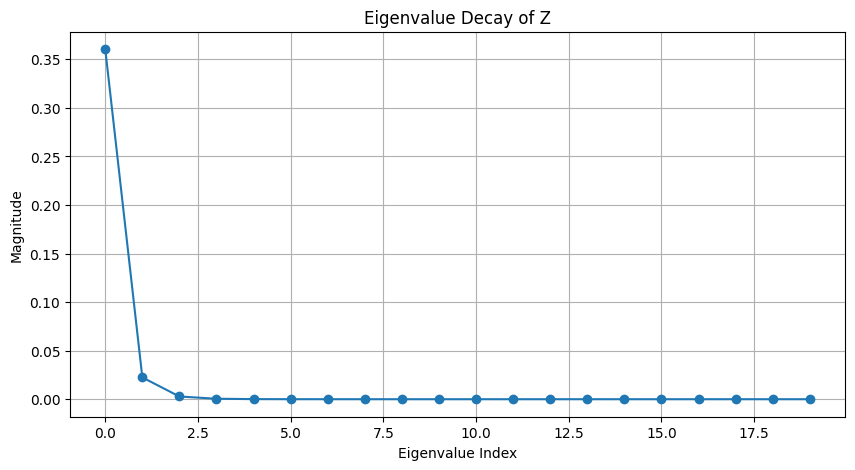

In [17]:
eigenvalues, eigenvectors = np.linalg.eig(Z)

# Sort eigenvalues by magnitude (descending)
order = np.argsort(np.abs(eigenvalues))[::-1]

sorted_eigenvalues = np.abs(eigenvalues)[order]

# Plot eigenvalue decay
plt.figure(figsize=(10, 5))

plt.plot(sorted_eigenvalues[:20], marker='o')

plt.title("Eigenvalue Decay of Z")

plt.xlabel("Eigenvalue Index")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()

In [ ]:
def online_spectral_filtering(A, B, C, filters, eps = 1e-3):
    """ Filters: [phi_1 ... phi_h] with $\phi_i \in \R^{T}$ => filters of size (Txh)"""
    T, h = filters.shape

    A = eps * np.eye(h)
    v = np.zeros(h,1)

    n, m = A.shape
    p, q = B.shape
    r, s = C.shape

    x = np.zeros((T + 1, n))
    u = np.random.randn(T, q) * 0.5
    y = np.zeros((T, r))

    for t in range(T):
        noise = 0.05 * np.random.randn(1)
        x[t + 1] = A @ x[t] + B @ u[t] + noise
        y[t] = C @ x[t]


# Spectral Decomposition using Singular Value Decomposition (SVD)

In this section, we apply Singular Value Decomposition (SVD) to the Hankel matrix.

The decomposition is given by:


$H = U \Sigma V^\top$

where:
- $U$ contains the left singular vectors;
- $\Sigma$ is the diagonal matrix containing the singular values;
- $V^\top$ contains the right singular vectors.

The objective of this step is to identify the dominant spectral modes of the temporal dynamics.

The singular vectors represent directions of maximum energy and variance in the temporal signal.

The singular values indicate how important each mode is.

The key idea behind spectral filtering is that many dynamical systems can be approximated using only a few dominant modes.

Instead of learning the entire temporal history explicitly, we project the signal onto a low-dimensional spectral basis.

This highly reduces:

- computational complexity;
- noise sensitivity;
- dimensionality.

The selected singular vectors become the spectral filters used later for feature extraction.

In [19]:
# ============================================================
# 3. Spectral decomposition
# ============================================================

# SVD da Hankel
U, S, Vt = np.linalg.svd(Z, full_matrices=False)

# Number of spectral filters to keep 
# #TODO: What's the best way to choose this? Maybe based on the singular values? Or maybe based on the reconstruction error? Or maybe based on the application? For example, if we want to do denoising, we might want to keep more filters. If we want to do dimensionality reduction, we might want to keep fewer filters.)
# I think we can use elbow method to choose the number of filters. We can plot the singular values and look for the elbow point where the singular values start to decay rapidly. This point can be a good choice for the number of filters to keep.
k = 2

spectral_filters = U[:, :k]

print("Filtros espectrais:")
print(spectral_filters.shape)

Filtros espectrais:
(300, 2)


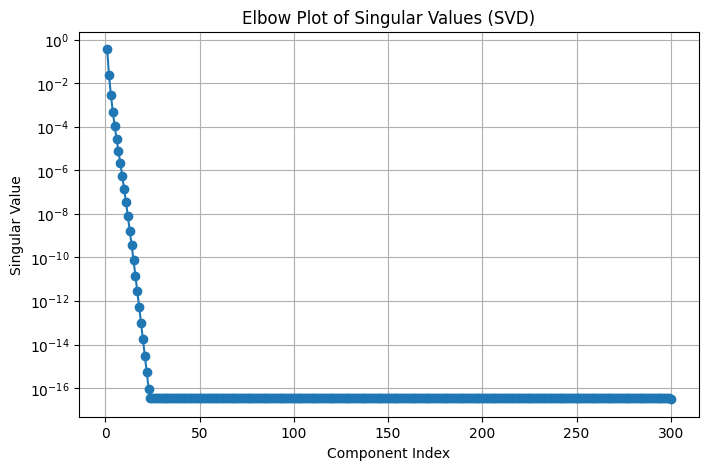

Filtros espectrais:
(300, 1)


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 3. Spectral decomposition
# ============================================================

# SVD da Hankel
U, S, Vt = np.linalg.svd(Z, full_matrices=False)

# ============================================================
# Elbow Plot
# ============================================================

plt.figure(figsize=(8, 5))

# Singular values
plt.plot(
    range(1, len(S) + 1),
    S,
    marker='o'
)

plt.xlabel("Component Index")
plt.ylabel("Singular Value")
plt.title("Elbow Plot of Singular Values (SVD)")
plt.grid(True)

# Opcional: escala log ajuda bastante
plt.yscale("log")

plt.show()

# ============================================================
# Escolha do número de filtros espectrais
# ============================================================

# Exemplo:
k = 1

spectral_filters = U[:, :k]

print("Filtros espectrais:")
print(spectral_filters.shape)

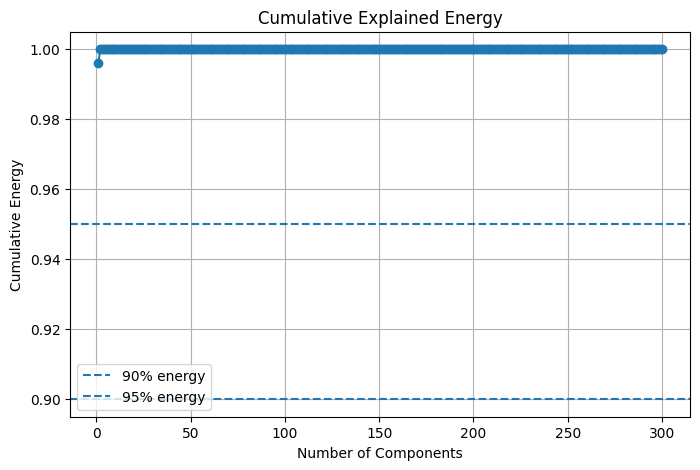

In [23]:
energy = np.cumsum(S**2) / np.sum(S**2)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(energy)+1), energy, marker='o')

plt.axhline(0.90, linestyle='--', label='90% energy')
plt.axhline(0.95, linestyle='--', label='95% energy')

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Energy")
plt.title("Cumulative Explained Energy")
plt.grid(True)
plt.legend()

plt.show()

# Building Spectral Features

This section projects temporal windows onto the learned spectral basis.

The objective is to transform raw temporal signals into compact spectral representations.

For each temporal window:

1. a segment of the signal is extracted;
2. the segment is projected onto the spectral filters;
3. the projection coefficients become the new features.

Mathematically, the operation corresponds to:

$$\phi_t = U_k^\top x_t$$

where:

- $U_k$ are the selected spectral filters;
- $x_t$ is the temporal window;
- $\phi_t$ are the spectral features.

This step is fundamental because the online learning algorithm does not operate directly on raw signals.

Instead, it learns over a compressed representation of the dynamics.

The spectral features capture:

- dominant frequencies;
- temporal patterns;
- long-term dependencies;
- latent modes of the system.

However, unlike fixed Fourier bases, the spectral basis is learned directly from the data structure itself.

In [30]:
# ============================================================
# 4. Building spectral features
# ============================================================

def spectral_features(signal, filters):
    """
    Projects temporal windows onto spectral filters.
    """

    h = filters.shape[0]
    N = len(signal) - h

    X = []

    for t in range(N):

        window = signal[t:t + h].flatten()

        feats = filters.T @ window

        X.append(feats)

    return np.array(X)

X_spec = spectral_features(y, spectral_filters)

# Future targets
y_target = y[hankel_size:].flatten()

# Online Learning with VAW (Vovk-Azoury-Warmuth)

This section implements the VAW online learning algorithm.

The VAW algorithm is a second-order online regression method designed for sequential prediction problems.

The predictor follows:

$\hat{y}_t = w_t^\top x_t$

where:

- $x_t$ are the spectral features;
- $w_t$ are the adaptive parameters.

Unlike standard gradient descent, VAW incorporates second-order information through a covariance matrix.

The update mechanism resembles:

- Recursive Least Squares (RLS);
- Online Newton Step;
- Kalman filtering.

The covariance matrix accumulates geometric information about the observed data:

$$\Chi = \sum_{i=1}^{t} x_i x_i^\top$$

This matrix captures:

- feature correlations;
- directional importance;
- input geometry.

The advantage of second-order methods is faster adaptation and improved stability compared to first-order gradient methods.

This is especially important in dynamical systems because temporal data often exhibit:

- strong correlations;
- non-stationarity;
- changing dynamics.

The VAW algorithm is particularly suitable for online control and adaptive filtering due to its regret guarantees and efficient sequential updates.

In [31]:
# ============================================================
# 5. VAW (Vovk-Azoury-Warmuth)
# ============================================================

class VAWRegressor:
    """
    Simple implementation of the VAW algorithm.
    """

    def __init__(self, dim, alpha=1.0):

        self.dim = dim

        # Covariance matrix
        self.covar = alpha * np.eye(dim)

        # Accumulated target vector
        self.b = np.zeros(dim)

        self.w = np.zeros(dim)

    def predict(self, x):

        return self.w @ x

    def update(self, x, y):

        # Recursive Least Squares-style update

        self.covar += np.outer(x, x) # update covariance matrix

        self.b += y * x

        self.w = np.linalg.solve(self.covar, self.b)

# Online Sequential Learning

In this section, the model performs sequential prediction and online adaptation.

The process follows the online learning paradigm:

1. receive the current feature vector;
2. predict the output;
3. observe the true value;
4. update the model parameters.

The online loop simulates a real-world environment where the system evolves over time and predictions must be made immediately.

The model continuously refines its understanding of the system dynamics through incremental updates.

In [32]:
# ============================================================
# 6. Online learning
# ============================================================

model = VAWRegressor(dim=k, alpha=1.0)

preds = []

for t in range(len(X_spec)):

    x_t = X_spec[t]
    y_t = y_target[t]

    y_pred = model.predict(x_t)

    preds.append(y_pred)

    model.update(x_t, y_t)

preds = np.array(preds)

# Evaluating Prediction Performance

This section computes the Mean Squared Error (MSE) between predictions and ground truth values.

The MSE is defined as:

$$MSE = \frac{1}{N}\sum_{t=1}^{N}(y_t - \hat{y}_t)^2$$

This metric measures the average squared prediction error.

The squared formulation penalizes large deviations more strongly, making it particularly useful for evaluating regression and prediction models.

In dynamical systems, MSE provides an indication of:

- prediction accuracy;
- model adaptation quality;
- filtering effectiveness.

A lower MSE suggests that the spectral representation successfully captured the dominant temporal dynamics of the system.


===== Evaluation Metrics =====
MSE   : 0.116049
RMSE  : 0.340660
NMSE  : 0.281064
R²    : 0.718936


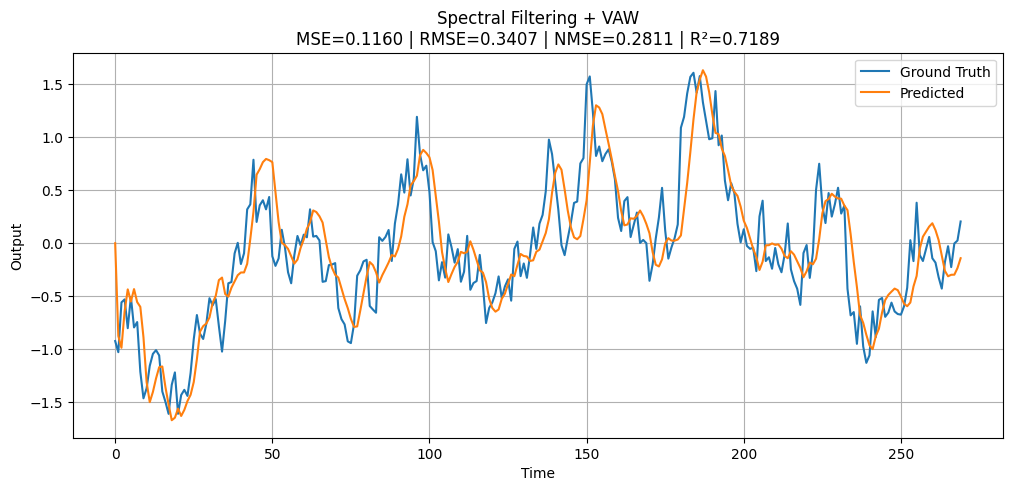

In [33]:
# ============================================================
# 7. Metrics
# ============================================================

# Mean Squared Error
mse = np.mean((preds - y_target) ** 2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Variance of the target signal
signal_variance = np.var(y_target)

# Normalized Mean Squared Error
nmse = mse / signal_variance

# R² Score
r2 = 1 - (
    np.sum((y_target - preds) ** 2) /
    np.sum((y_target - np.mean(y_target)) ** 2)
)

print("\n===== Evaluation Metrics =====")
print(f"MSE   : {mse:.6f}")
print(f"RMSE  : {rmse:.6f}")
print(f"NMSE  : {nmse:.6f}")
print(f"R²    : {r2:.6f}")

# ============================================================
# 8. Visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(y_target, label='Ground Truth')
plt.plot(preds, label='Predicted')

plt.title(
    f"Spectral Filtering + VAW\n"
    f"MSE={mse:.4f} | RMSE={rmse:.4f} | "
    f"NMSE={nmse:.4f} | R²={r2:.4f}"
)

plt.xlabel("Time")
plt.ylabel("Output")

plt.legend()

plt.grid(True)

plt.show()

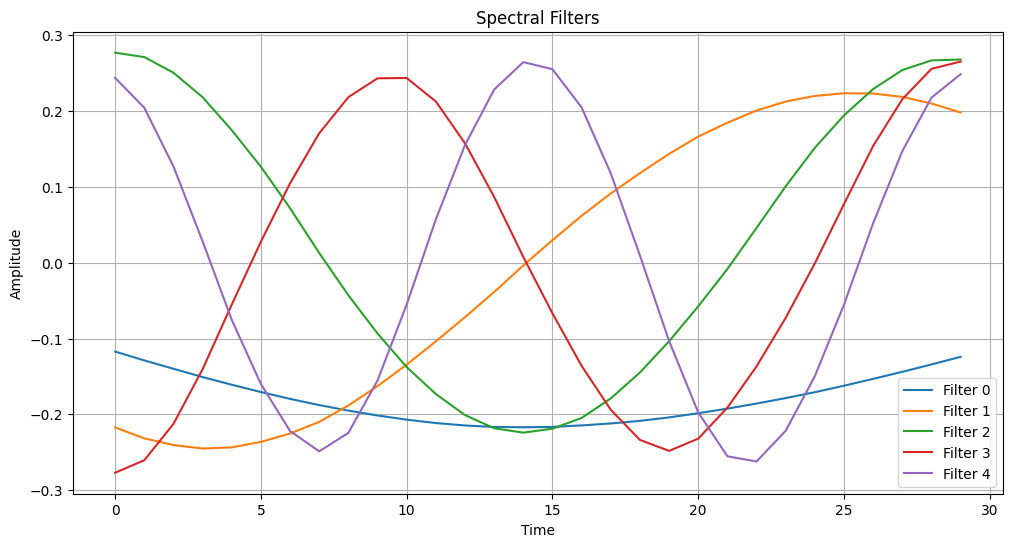

In [34]:

# ============================================================
# 9. Visualizing spectral filters
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(k):
    plt.plot(spectral_filters[:, i], label=f'Filter {i}')

plt.title("Spectral Filters")
plt.xlabel("Time")
plt.ylabel("Amplitude")

plt.legend()
plt.grid(True)

plt.show()

# Estudar escolha de parâmetros:

- k = 10 (número de filtros espectrais)
- hankel_size (memória temporal)
- alpha (Regularização adaptativa)

Theoretical Hankel operator shape:
(30, 30)

Z_T:
[[1.         0.5        0.33333333 0.25       0.2        0.16666667
  0.14285714 0.125      0.11111111 0.1        0.09090909 0.08333333
  0.07692308 0.07142857 0.06666667 0.0625     0.05882353 0.05555556
  0.05263158 0.05       0.04761905 0.04545455 0.04347826 0.04166667
  0.04       0.03846154 0.03703704 0.03571429 0.03448276 0.03333333]
 [0.5        0.33333333 0.25       0.2        0.16666667 0.14285714
  0.125      0.11111111 0.1        0.09090909 0.08333333 0.07692308
  0.07142857 0.06666667 0.0625     0.05882353 0.05555556 0.05263158
  0.05       0.04761905 0.04545455 0.04347826 0.04166667 0.04
  0.03846154 0.03703704 0.03571429 0.03448276 0.03333333 0.03225806]
 [0.33333333 0.25       0.2        0.16666667 0.14285714 0.125
  0.11111111 0.1        0.09090909 0.08333333 0.07692308 0.07142857
  0.06666667 0.0625     0.05882353 0.05555556 0.05263158 0.05
  0.04761905 0.04545455 0.04347826 0.04166667 0.04       0.03846154
  0.03703704 

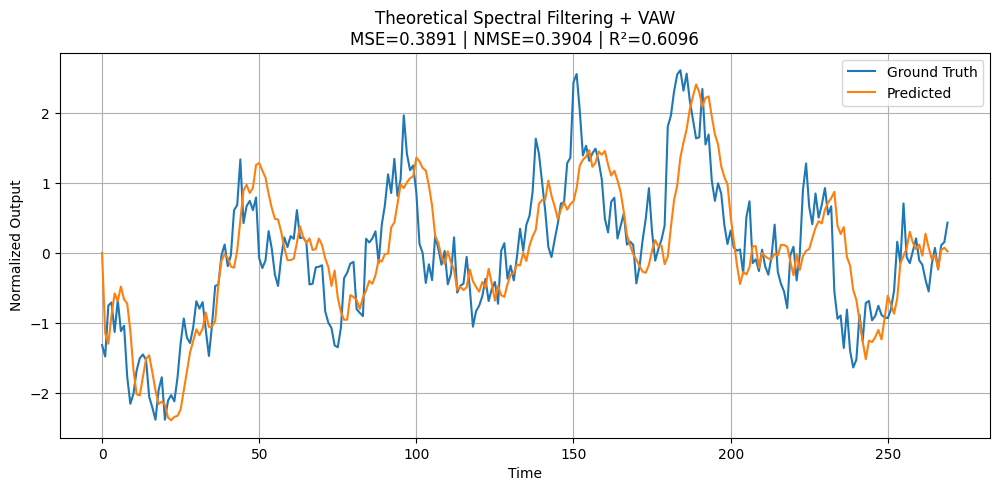

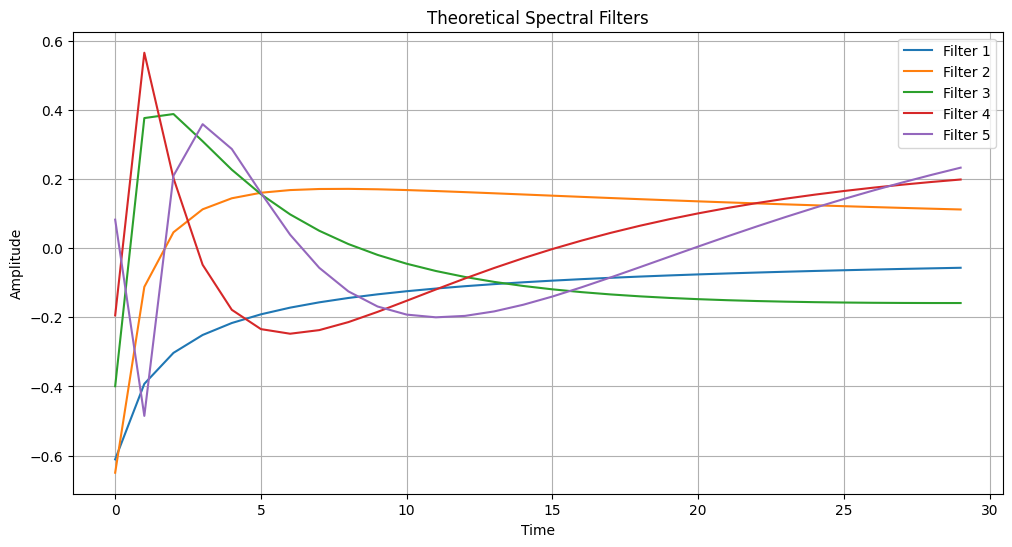

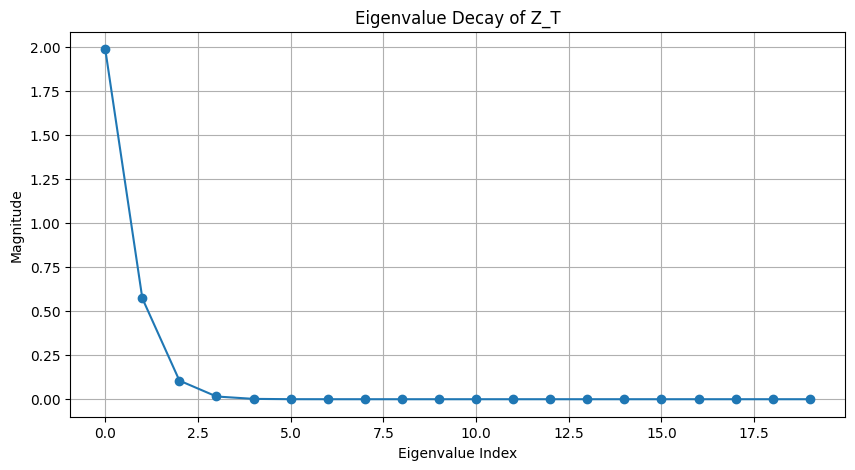

In [36]:
"""
Theoretical Spectral Filtering using the Hankel Operator Z_T
============================================================

This implementation follows the theoretical formulation presented in:

Chapter 11 — Spectral Filtering
Introduction to Online Control

Instead of constructing a data-driven Hankel matrix directly from
observed signals, we construct the theoretical Hankel operator:

    Z_T = ∫ μ_α μ_α^T dα

where:

    μ_α = (α - 1)[1, α, α², ..., α^(T-1)]^T

The eigenvectors of Z_T form the theoretical spectral basis used
for spectral filtering in Linear Dynamical Systems (LDS).

This implementation demonstrates:

1. Construction of the theoretical Hankel operator
2. Spectral decomposition
3. Projection of signals into the theoretical spectral basis
4. Online learning using VAW
5. Sequential prediction

Author: ChatGPT
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Generate a simple linear dynamical system
# ============================================================

np.random.seed(42)

T = 300

A = np.array([[0.95]])
B = np.array([[0.5]])
C = np.array([[1.0]])

x = np.zeros((T + 1, 1))
u = np.random.randn(T, 1) * 0.5
y = np.zeros((T, 1))

for t in range(T):

    noise = 0.05 * np.random.randn(1)

    x[t + 1] = A @ x[t] + B @ u[t] + noise

    y[t] = C @ x[t]

# ============================================================
# 2. Normalize signal
# ============================================================

y_mean = np.mean(y)
y_std = np.std(y)

y_norm = (y - y_mean) / y_std


# ============================================================
# 3. Construct theoretical Hankel operator Z_T
# ============================================================

def theoretical_hankel_operator(T_hankel=30):
    """
    Constructs the theoretical Hankel matrix:

        Z_T(i,j) = 1 / (i + j - 1)

    which corresponds to the continuous Hankel operator
    derived in the spectral filtering theory.

    This matrix is closely related to the Hilbert matrix
    and appears naturally from:

        Z_T = ∫ μ_α μ_α^T dα
    """

    Z = np.zeros((T_hankel, T_hankel))

    for i in range(T_hankel):

        for j in range(T_hankel):

            # +1 because Python indexing starts at 0
            Z[i, j] = 1.0 / (i + j + 1)

    return Z

hankel_size = 30

Z_T = theoretical_hankel_operator(hankel_size)

print("Theoretical Hankel operator shape:")
print(Z_T.shape)

print("\nZ_T:")
print(Z_T)

# # ============================================================
# # 3. Construct theoretical Hankel operator Z_T
# # ============================================================

# def theoretical_hankel_operator(T_hankel=30, n_alpha=1000):
#     """
#     Constructs the theoretical Hankel operator:

#         Z_T = ∫ μ_α μ_α^T dα

#     using numerical integration.
#     """

#     alphas = np.linspace(0, 1, n_alpha)

#     Z = np.zeros((T_hankel, T_hankel))

#     for alpha in alphas:

#         mu_alpha = np.array([
#             (alpha - 1) * (alpha ** i)
#             for i in range(T_hankel)
#         ])

#         Z += np.outer(mu_alpha, mu_alpha)

#     Z /= n_alpha

#     return Z

# hankel_size = 30

# Z_T = theoretical_hankel_operator(
#     T_hankel=hankel_size,
#     n_alpha=2000
# )

# print("Theoretical Hankel operator shape:")
# print(Z_T.shape)

# ============================================================
# 4. Spectral decomposition of Z_T
# ============================================================

eigenvalues, eigenvectors = np.linalg.eigh(Z_T)

# Sort descending
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Number of spectral filters
k = 5

spectral_filters = eigenvectors[:, :k]

print("\nSpectral filters shape:")
print(spectral_filters.shape)

# ============================================================
# 5. Construct spectral features
# ============================================================

def spectral_features(signal, filters):
    """
    Projects temporal windows onto the theoretical
    spectral basis.
    """

    h = filters.shape[0]

    N = len(signal) - h

    X = []

    for t in range(N):

        window = signal[t:t+h].flatten()

        feats = filters.T @ window

        X.append(feats)

    return np.array(X)

X_spec = spectral_features(
    y_norm,
    spectral_filters
)

# ============================================================
# 6. Normalize spectral features
# ============================================================

X_mean = np.mean(X_spec, axis=0)
X_std = np.std(X_spec, axis=0)

X_spec = (X_spec - X_mean) / (X_std + 1e-8)

# ============================================================
# 7. Targets
# ============================================================

y_target = y_norm[hankel_size:].flatten()

# ============================================================
# 8. VAW Regressor
# ============================================================

class VAWRegressor:
    """
    Vovk-Azoury-Warmuth online regression.
    """

    def __init__(self, dim, alpha=1.0):

        self.dim = dim

        self.A = alpha * np.eye(dim)

        self.b = np.zeros(dim)

        self.w = np.zeros(dim)

    def predict(self, x):

        return self.w @ x

    def update(self, x, y):

        self.A += np.outer(x, x)

        self.b += y * x

        self.w = np.linalg.solve(self.A, self.b)

# ============================================================
# 9. Online learning
# ============================================================

model = VAWRegressor(dim=k, alpha=1.0)

preds = []

for t in range(len(X_spec)):

    x_t = X_spec[t]

    y_t = y_target[t]

    y_pred = model.predict(x_t)

    preds.append(y_pred)

    model.update(x_t, y_t)

preds = np.array(preds)

# ============================================================
# 10. Metrics
# ============================================================

mse = np.mean((preds - y_target) ** 2)

rmse = np.sqrt(mse)

signal_variance = np.var(y_target)

nmse = mse / signal_variance

r2 = 1 - (
    np.sum((y_target - preds) ** 2)
    /
    np.sum((y_target - np.mean(y_target)) ** 2)
)

print("\n===== Evaluation Metrics =====")
print(f"MSE   : {mse:.6f}")
print(f"RMSE  : {rmse:.6f}")
print(f"NMSE  : {nmse:.6f}")
print(f"R²    : {r2:.6f}")

# ============================================================
# 11. Prediction visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(y_target, label='Ground Truth')

plt.plot(preds, label='Predicted')

plt.title(
    "Theoretical Spectral Filtering + VAW\n"
    f"MSE={mse:.4f} | "
    f"NMSE={nmse:.4f} | "
    f"R²={r2:.4f}"
)

plt.xlabel("Time")

plt.ylabel("Normalized Output")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# 12. Visualize spectral filters
# ============================================================

plt.figure(figsize=(12, 6))

for i in range(k):

    plt.plot(
        spectral_filters[:, i],
        label=f'Filter {i+1}'
    )

plt.title("Theoretical Spectral Filters")

plt.xlabel("Time")

plt.ylabel("Amplitude")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# 13. Visualize eigenvalue decay
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(eigenvalues[:20], marker='o')

plt.title("Eigenvalue Decay of Z_T")

plt.xlabel("Eigenvalue Index")

plt.ylabel("Magnitude")

plt.grid(True)

plt.show()